# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse

In [289]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [ ]:
def adf_test_results(combined_df):
    result = adfuller(combined_df.dropna()) # dropna() to handle potential missing values
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4],
        'is_stationary': result[1] < 0.05 # Check p-value against 0.05
    }

In [291]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData1.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [292]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:04:46,2,02/27/2025 10:04:46 AM,80.19,78.64,76.12,77.16,78.88,78.26,sheet1
2025-02-27 10:04:48,3,02/27/2025 10:04:48 AM,80.21,78.65,76.10,77.14,78.87,78.24,sheet1
2025-02-27 10:04:50,4,02/27/2025 10:04:50 AM,80.06,78.64,76.12,77.17,78.87,78.12,sheet1
2025-02-27 10:04:52,5,02/27/2025 10:04:52 AM,80.06,78.64,76.12,77.18,78.88,78.12,sheet1


In [293]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        302401 non-null  int64  
 1   Time         302401 non-null  str    
 2   CH01(%)      302401 non-null  float64
 3   CH02(%)      302401 non-null  float64
 4   CH03(%)      302401 non-null  float64
 5   CH04(%)      302401 non-null  float64
 6   CH05(%)      302401 non-null  float64
 7   CH06(%)      302401 non-null  float64
 8   SourceSheet  302401 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 23.1 MB


In [294]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [295]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        302401 non-null  int64  
 1   CH01(%)      302401 non-null  float64
 2   CH02(%)      302401 non-null  float64
 3   CH03(%)      302401 non-null  float64
 4   CH04(%)      302401 non-null  float64
 5   CH05(%)      302401 non-null  float64
 6   CH06(%)      302401 non-null  float64
 7   SourceSheet  302401 non-null  str    
dtypes: float64(6), int64(1), str(1)
memory usage: 20.8 MB


In [296]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [297]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [298]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Index    302401 non-null  int64  
 1   CH01(%)  302401 non-null  float64
 2   CH02(%)  302401 non-null  float64
 3   CH03(%)  302401 non-null  float64
 4   CH04(%)  302401 non-null  float64
 5   CH05(%)  302401 non-null  float64
 6   CH06(%)  302401 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 18.5 MB


In [299]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:04:46,2,80.19,78.64,76.12,77.16,78.88,78.26
2025-02-27 10:04:48,3,80.21,78.65,76.10,77.14,78.87,78.24
2025-02-27 10:04:50,4,80.06,78.64,76.12,77.17,78.87,78.12
2025-02-27 10:04:52,5,80.06,78.64,76.12,77.18,78.88,78.12


In [301]:
# Apply the function to all columns (excluding date/index if necessary)
results = {col: adf_test_results(combined_df[col]) for col in combined_df.columns if col != 'date_column_name'}
results_df = pd.DataFrame(results).T # Transpose for better readability
print(results_df)

c:\Users\sulaiman.at\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


        ADF Statistic   p-value  \
Index      354.865475       1.0   
CH01(%)     -0.664224    0.8558   
CH02(%)     -0.353466  0.917583   
CH03(%)     -0.737826  0.836707   
CH04(%)     -1.509226  0.528943   
CH05(%)     -0.620539  0.866273   
CH06(%)     -0.436706  0.903787   

                                           Critical Values is_stationary  
Index    {'1%': -3.430371629359032, '5%': -2.8615495599...         False  
CH01(%)  {'1%': -3.4303716312192623, '5%': -2.861549560...         False  
CH02(%)  {'1%': -3.4303716312192623, '5%': -2.861549560...         False  
CH03(%)  {'1%': -3.4303716282859678, '5%': -2.861549559...         False  
CH04(%)  {'1%': -3.4303716311477093, '5%': -2.861549560...         False  
CH05(%)  {'1%': -3.4303716312192623, '5%': -2.861549560...         False  
CH06(%)  {'1%': -3.4303716312192623, '5%': -2.861549560...         False  


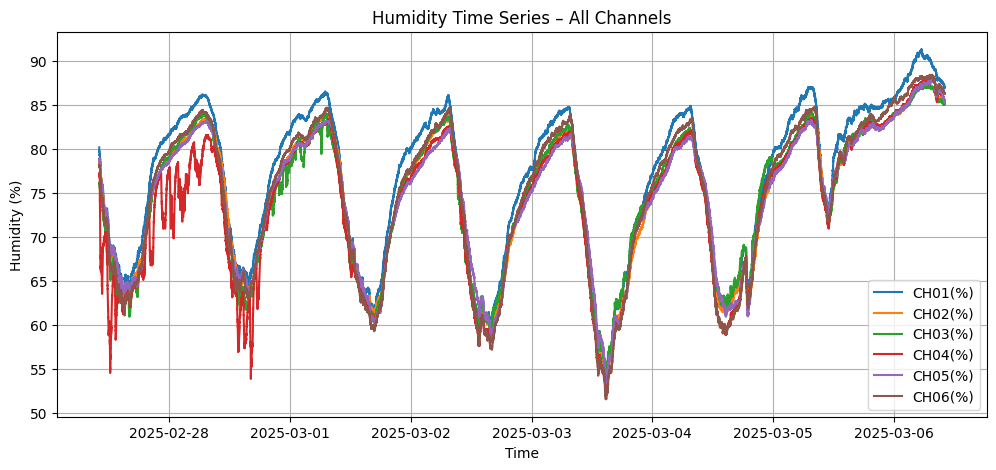

In [302]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


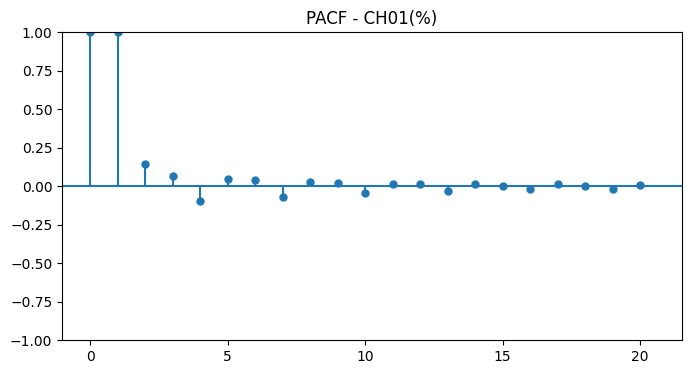

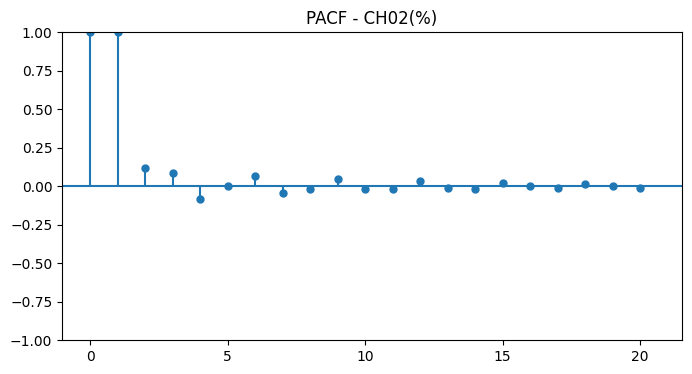

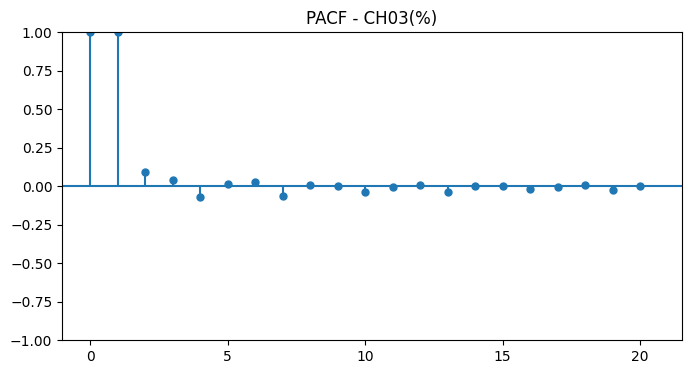

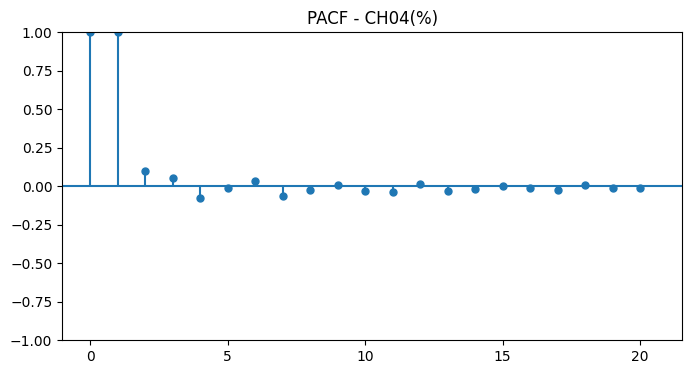

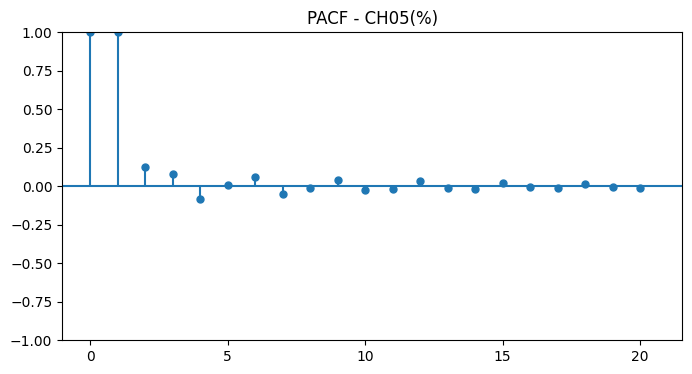

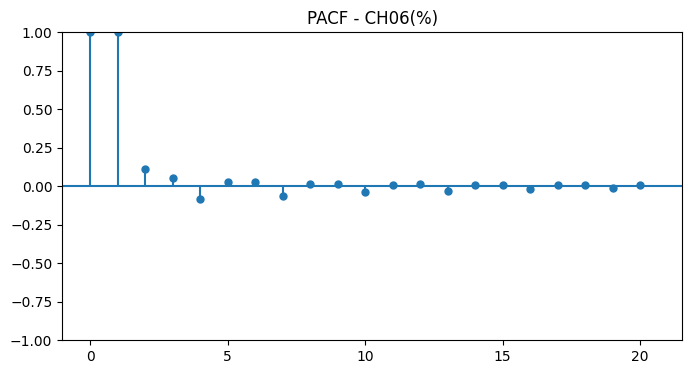

In [303]:
for column in combined_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    # 'method' can be 'yw' (default) or 'ols'
    plot_pacf(combined_df[column].dropna(), lags=20, ax=ax, title=f'PACF - {column}')
    plt.show()

In [304]:
# Choose one channel
y = combined_df['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest 30 minutes and aggregate duplicates
y.index = y.index.round('30min')
y = y.groupby(level=0).mean()

# Enforce strict 30-min frequency
y = y.asfreq('30min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [305]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1095.198, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3066.002, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1102.303, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1083.182, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1106.255, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1094.984, Time=0.20 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1094.795, Time=0.24 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1032.651, Time=0.40 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1095.398, Time=0.16 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1095.558, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=1086.278, T

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  269
Model:               SARIMAX(2, 0, 4)   Log Likelihood                -486.131
Date:                Mon, 30 Mar 2026   AIC                            988.261
Time:                        13:59:18   BIC                           1017.019
Sample:                    02-27-2025   HQIC                           999.811
                         - 03-05-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.3455      0.198      6.787      0.000       0.957       1.734
ar.L1          1.9568      0.010    195.455      0.000       1.937       1.976
ar.L2         -0.9755      0.009   -114.269      0.000      -0.992      -0.959
ma.L1         -0.9905      0.058    -16.999      0.000      -1.105      -0.876
ma.L2         -0.1474      0.065     -2.260      0.024      -0.275      -0.020
ma.L3          0.5755      0.062      9.223      0.000       0.453       0.698
ma.L4         -0.3494      0.059     -5.967      0.000      -0.464      -0.235
sigma2         2.1313      0.131     16.329      0.000       1.875       2.387
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               187.86
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                            -0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

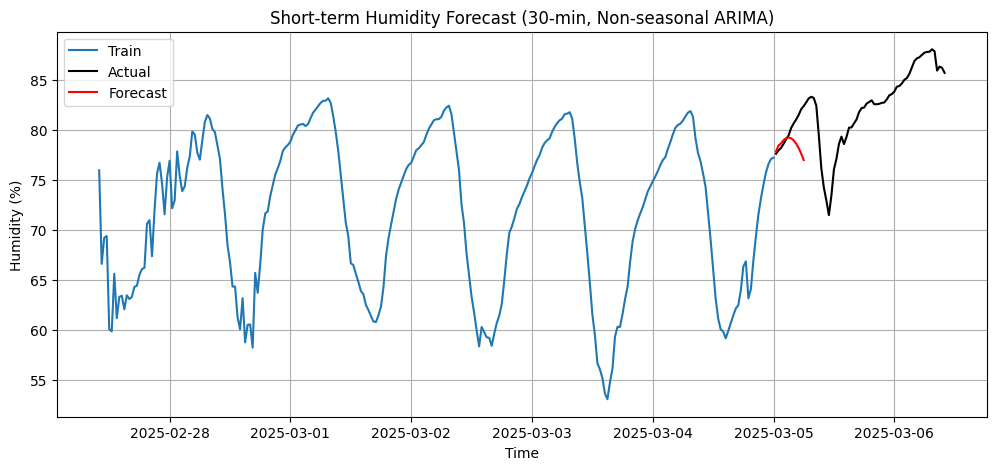

In [306]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='30min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (30-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


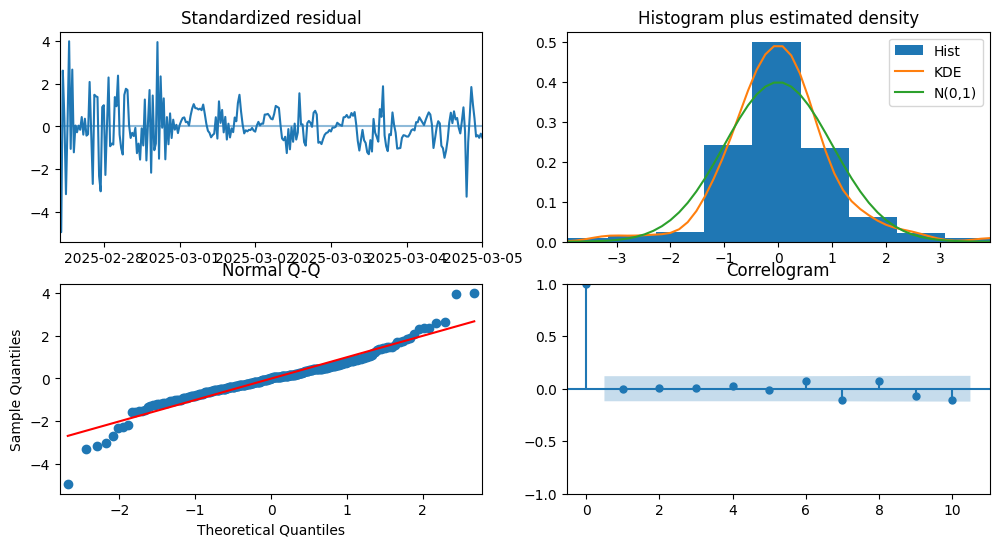

In [307]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [308]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 1.6814932173689658
Simple  ARIMA(1,0,1) MAE: 3.9203962214516843


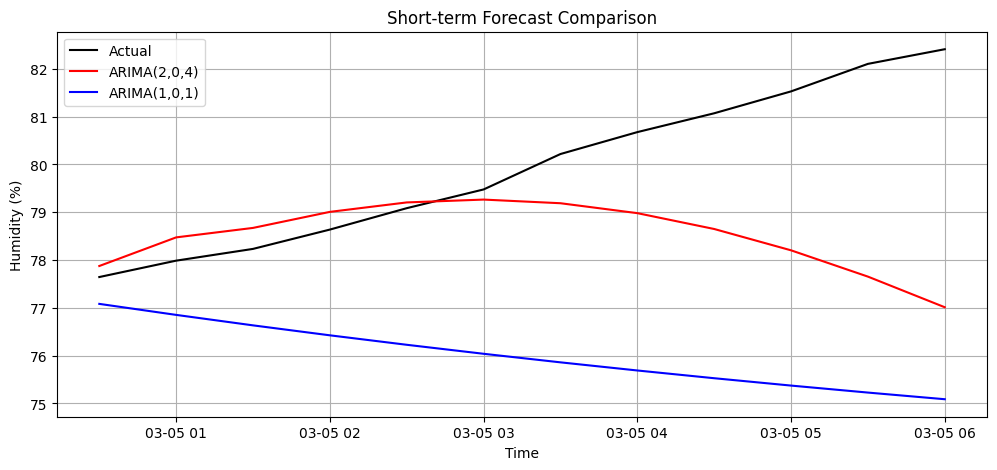

In [309]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
